# Regresión lineal aplicada a datos diarios de NO₂

En este notebook se analiza la relación entre la **concentración máxima diaria de NO₂** y el **AQI diario** mediante regresión lineal.


## 1. Importación de librerías


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


## 2. Carga de los datos


In [3]:
df = pd.read_csv('/content/NO2_daily_aqs_data_downloaded_2026-09-17 22_12_08.csv')
df.head()


,Date,Site ID,POC,Daily Max NO2 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,...,Elevation (m),Measurement Scale,Measurement Scale Definition,Monitor Type,Monitoring Agency,Monitoring Objective,NAAQS Primary Monitor?,Networks,Probe Height (m),QA Primary Monitor?
0,2022-01-01,10730023,1,1.9,Parts per billion,1,North Birmingham,24,100,42602,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,Y,NCORE,17.5,NaN
1,2022-01-02,10730023,1,4.2,Parts per billion,4,North Birmingham,24,100,42602,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,Y,NCORE,17.5,NaN
2,2022-01-03,10730023,1,2.2,Parts per billion,2,North Birmingham,10,42,42602,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,Y,NCORE,17.5,NaN
3,2022-01-04,10730023,1,8.1,Parts per billion,8,North Birmingham,9,38,42602,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,Y,NCORE,17.5,NaN
4,2022-01-05,10730023,1,29.4,Parts per billion,27,North Birmingham,16,67,42602,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,Y,NCORE,17.5,NaN


## 3. Información general


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1317 entries, 0 to 1316
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          1317 non-null   object 
 1   Site ID                       1317 non-null   int64  
 2   POC                           1317 non-null   int64  
 3   Daily Max NO2 Concentration   1317 non-null   float64
 4   Units                         1317 non-null   object 
 5   Daily AQI Value               1317 non-null   int64  
 6   Local Site Name               1317 non-null   object 
 7   Daily Obs Count               1317 non-null   int64  
 8   Percent Complete              1317 non-null   int64  
 9   AQS Parameter Code            1317 non-null   int64  
 10  AQS Parameter Description     1317 non-null   object 
 11  Method Code                   1317 non-null   int64  
 12  Method Description            1317 non-null   object 
 13  CBS

## 4. Estadística descriptiva


In [5]:
df.describe()


,Site ID,POC,Daily Max NO2 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,Site Latitude,Site Longitude,Elevation (m),Probe Height (m),QA Primary Monitor?
count,1.317000e+03,1317.0,1317.000000,1317.000000,1317.000000,1317.000000,1317.0,1317.0,1317.0,1317.000000,1317.000000,1317.000000,718.0,0.0
mean,1.073095e+07,1.0,19.920805,18.340167,22.788914,94.991648,42602.0,200.0,13820.0,33.538670,-86.828241,180.059130,17.5,NaN
std,1.014221e+03,0.0,8.991656,8.494572,2.870206,11.919592,0.0,0.0,0.0,0.015756,0.014502,3.350516,0.0,NaN
min,1.073002e+07,1.0,1.900000,1.000000,2.000000,8.000000,42602.0,200.0,13820.0,33.521427,-86.844112,177.000000,17.5,NaN
25%,1.073002e+07,1.0,12.800000,11.000000,24.000000,100.000000,42602.0,200.0,13820.0,33.521427,-86.844112,177.000000,17.5,NaN
50%,1.073002e+07,1.0,18.900000,17.000000,24.000000,100.000000,42602.0,200.0,13820.0,33.553056,-86.815000,177.000000,17.5,NaN
75%,1.073206e+07,1.0,26.300000,25.000000,24.000000,100.000000,42602.0,200.0,13820.0,33.553056,-86.815000,183.726000,17.5,NaN
max,1.073206e+07,1.0,50.300000,47.000000,24.000000,100.000000,42602.0,200.0,13820.0,33.553056,-86.815000,183.726000,17.5,NaN


## 5. Columnas disponibles


In [6]:
df.columns


Index(['Date', 'Site ID', 'POC', 'Daily Max NO2 Concentration', 'Units',
       'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name',
       'Site Latitude', 'Site Longitude', 'Dominant Source', 'Elevation (m)',
       'Measurement Scale', 'Measurement Scale Definition', 'Monitor Type',
       'Monitoring Agency', 'Monitoring Objective', 'NAAQS Primary Monitor?',
       'Networks', 'Probe Height (m)', 'QA Primary Monitor?'],
      dtype='object')

## 6. Relación entre NO₂ y AQI


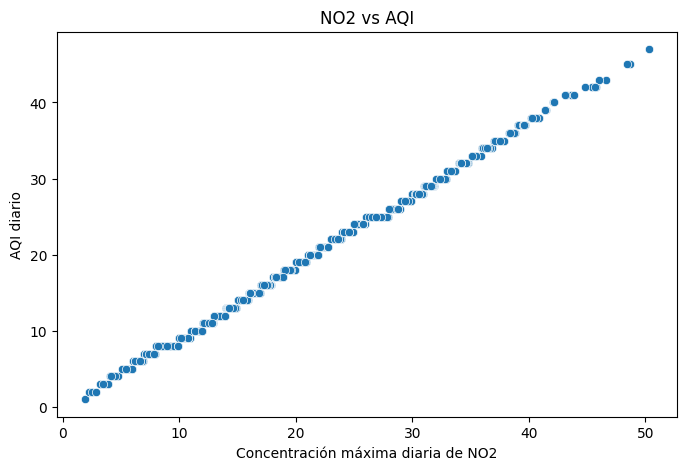

In [7]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Daily Max NO2 Concentration',
    y='Daily AQI Value',
    data=df
)

plt.xlabel('Concentración máxima diaria de NO2')
plt.ylabel('AQI diario')
plt.title('NO2 vs AQI')

plt.show()


## 7. Definición de variables


In [8]:
X = df[['Daily Max NO2 Concentration']]  # variable predictora
y = df['Daily AQI Value']                # variable que queremos predecir


## 8. División en entrenamiento y prueba


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,      # 30% prueba y 70% entrenamiento
    random_state=101
)


## 9. Creación del modelo de regresión lineal


In [10]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()


## 10. Entrenamiento del modelo


In [11]:
lm.fit(X_train, y_train)


LinearRegression()

## 11. Predicciones


In [12]:
pred = lm.predict(X_test)
pred[:10]


array([12.74213066, 18.31511116, 24.73820733, 14.91464848, 24.92712193,
       16.80379441, 36.16754023, 20.86545817,  5.9412053 , 10.66407013])

## 12. Intercepto y coeficiente


In [13]:
print("Intercepto:", lm.intercept_)
print("Coeficiente:", lm.coef_)


Intercepto: -0.48189087315543944
Coeficiente: [0.94457297]


## 13. Evaluación del modelo


In [14]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 0.31902517931152424
MSE: 0.15461309572562648
RMSE: 0.3932087177640222
R²: 0.9980382089302814


## 14. Valores reales vs valores predichos


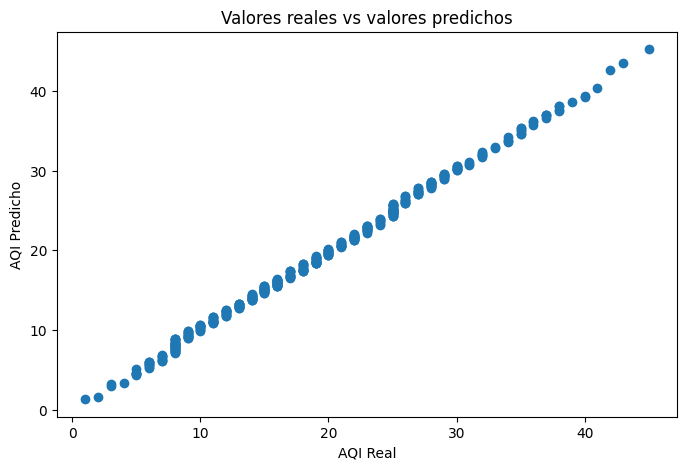

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, pred)

plt.xlabel('AQI Real')
plt.ylabel('AQI Predicho')
plt.title('Valores reales vs valores predichos')

plt.show()


## 15. Línea de regresión


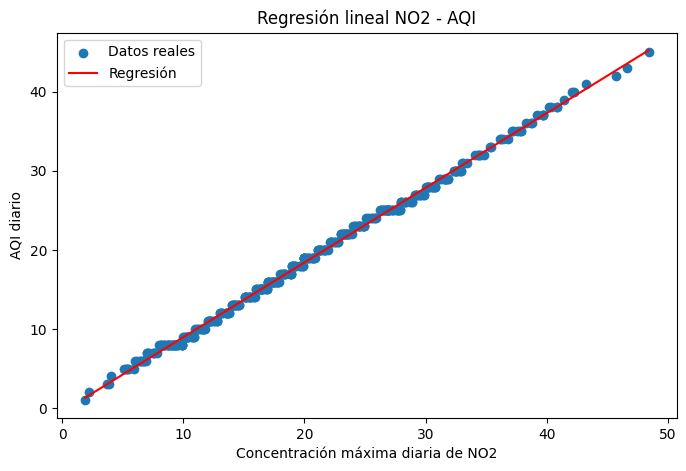

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_test['Daily Max NO2 Concentration'],
    y_test,
    label='Datos reales'
)

orden = np.argsort(X_test['Daily Max NO2 Concentration'])

plt.plot(
    X_test['Daily Max NO2 Concentration'].iloc[orden],
    pred[orden],
    color='red',
    label='Regresión'
)

plt.xlabel('Concentración máxima diaria de NO2')
plt.ylabel('AQI diario')
plt.title('Regresión lineal NO2 - AQI')

plt.legend()
plt.show()


## 16. Análisis de residuos


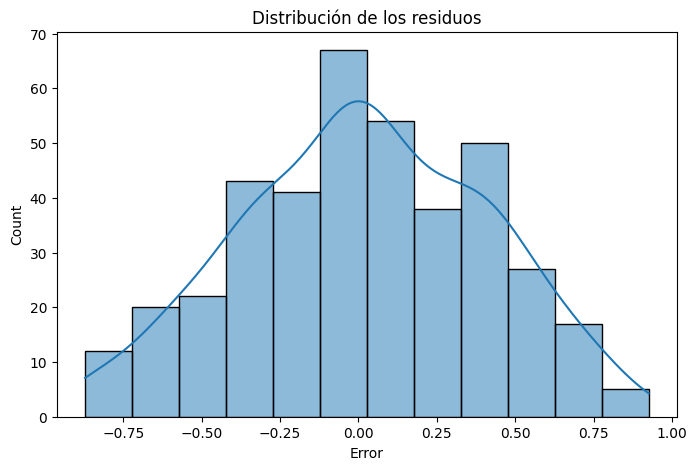

In [17]:
residuos = y_test - pred

plt.figure(figsize=(8,5))

sns.histplot(residuos, kde=True)

plt.xlabel('Error')
plt.title('Distribución de los residuos')

plt.show()


## 17. Validación cruzada


In [18]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    lm,
    X,
    y,
    cv=cv,
    scoring='r2'
)

scores


array([0.99782699, 0.99783568, 0.99805857, 0.99752922, 0.99792623])

## 18. Resultados de la validación cruzada


In [19]:
print("R² de cada fold:")
print(scores)

print("\nR² promedio:")
print(scores.mean())

print("\nDesviación estándar:")
print(scores.std())


R² de cada fold:
[0.99782699 0.99783568 0.99805857 0.99752922 0.99792623]

R² promedio:
0.9978353390251243

Desviación estándar:
0.0001742836967489462


## 19. Gráfico de validación cruzada


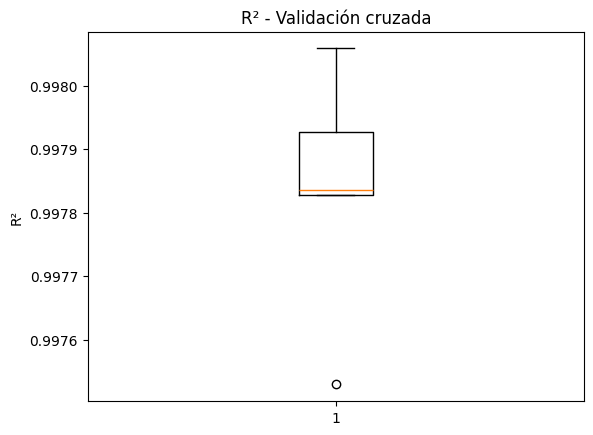

In [20]:
plt.figure()

plt.boxplot(scores)

plt.title('R² - Validación cruzada')
plt.ylabel('R²')

plt.show()
